<a href="https://colab.research.google.com/github/Varshi040104/RAG-Ecommerce-Assistant/blob/main/Py_Pandas%2CML_%26_GenAI_for_Ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
pip install sentence-transformers openai anthropic faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 65.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
orders = pd.read_csv("/content/orders.csv")
customers = pd.read_csv("/content/customers.csv")
products = pd.read_csv("/content/products.csv")

In [ ]:
#checking the shape of each dataset
print(orders.shape)
print(customers.shape)
print(products.shape)

(12480, 9)
(1500, 5)
(600, 8)


In [ ]:
#checking the order's top columns
orders.head()

,order_id,customer_id,product_id,category,brand,price,quantity,order_date,city
0,ORD10001,CUST042,PRD017,Electronics,Boat,1299.0,1,2024-01-01,Mumbai
1,ORD10002,CUST119,PRD221,Fashion,Levis,2199.0,1,2024-01-01,Mumbai
2,ORD10003,CUST042,PRD088,Home & Kitchen,Milton,649.0,2,2024-01-02,Mumbai
3,ORD10004,CUST311,PRD500,Electronics,Samsung,18999.0,1,2024-01-02,Mumbai
4,ORD10005,CUST008,PRD156,Beauty,Lakme,399.0,3,2024-01-02,Bengaluru


In [ ]:
#checking the information of orders dataset
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12480 entries, 0 to 12479
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     12480 non-null  object 
 1   customer_id  12480 non-null  object 
 2   product_id   12480 non-null  object 
 3   category     12480 non-null  object 
 4   brand        12360 non-null  object 
 5   price        12480 non-null  float64
 6   quantity     12480 non-null  int64  
 7   order_date   12480 non-null  object 
 8   city         12480 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 877.6+ KB


In [ ]:
orders[["price", "quantity"]].describe()

,price,quantity
count,12480.000000,12480.000000
mean,1274.489744,1.663381
std,1728.344159,1.144670
min,149.000000,1.000000
25%,440.000000,1.000000
50%,776.000000,1.000000
75%,1555.000000,2.000000
max,18999.000000,8.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
customers = pd.read_csv("customers.csv", parse_dates=["signup_date"])
products = pd.read_csv("products.csv")

orders["revenue"] = orders["price"] * orders["quantity"]
df = (orders
      .merge(customers, on="customer_id", how="left")
      .merge(products, on="product_id", how="left", suffixes=("", "_prod")))
df["brand"] = df["brand"].fillna("Unknown")

mean: 1274.49
median: 776.0
skew: 6.44


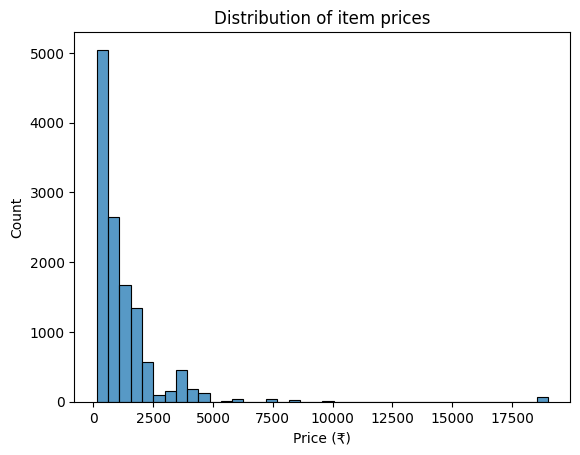

In [ ]:
sns.histplot(df["price"], bins=40)
plt.xlabel("Price (₹)")
plt.title("Distribution of item prices")
print("mean:", round(df["price"].mean(), 2))
print("median:", df["price"].median())
print("skew:", round(df["price"].skew(), 2))
plt.show()

In [ ]:
print("mean:", round(df["price"].mean(), 2))
print("median:", df["price"].median())
print("skew:", round(df["price"].skew(), 2))

mean: 1274.49
median: 776.0
skew: 6.44


In [ ]:
num_cols = ["price", "quantity", "revenue", "rating"]
df[num_cols].corr().round(2)

,price,quantity,revenue,rating
price,1.00,-0.21,0.90,0.09
quantity,-0.21,1.00,0.07,-0.02
revenue,0.90,0.07,1.00,0.08
rating,0.09,-0.02,0.08,1.00


<Axes: >

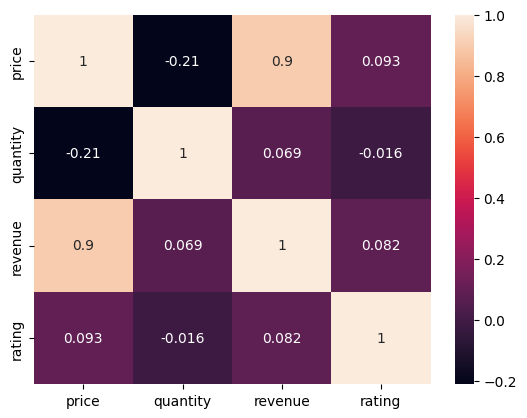

In [ ]:
(sns.heatmap(df[num_cols].corr(), annot=True))

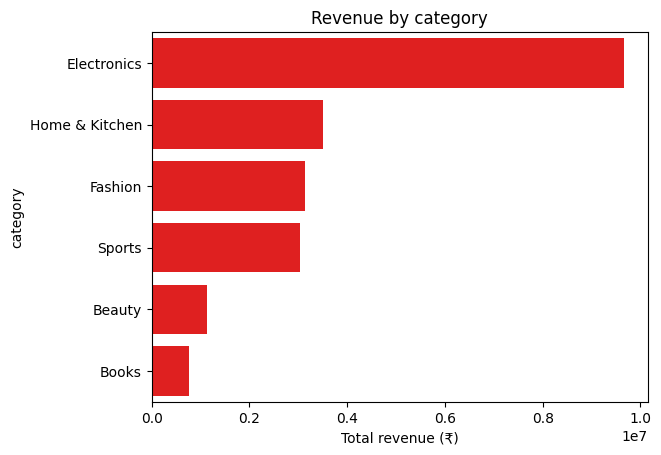

In [ ]:
cat_rev = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, color="red")
plt.xlabel("Total revenue (₹)")
plt.title("Revenue by category")
plt.show()

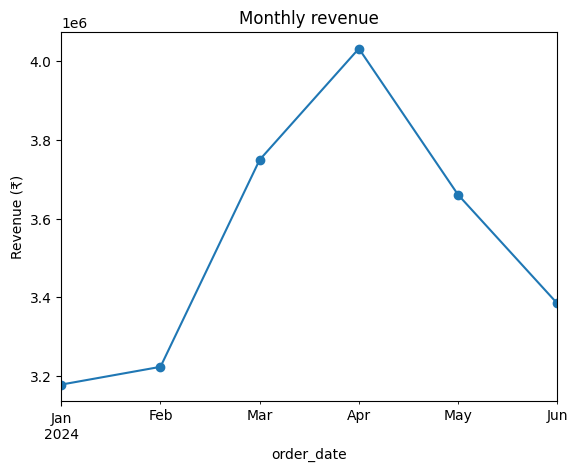

In [ ]:
monthly = (df.set_index("order_date")
             .resample("ME")["revenue"].sum())   # "ME" = month end
monthly.plot(marker="o")
plt.ylabel("Revenue (₹)")
plt.title("Monthly revenue")
plt.show()

In [ ]:
df["signup_month"] = df["signup_date"].dt.to_period("M")
cohort = df.groupby("signup_month")["revenue"].mean().round(0)
cohort.tail(4)

,revenue
signup_month,
2024-02,2029.0
2024-03,1799.0
2024-04,1374.0
2024-05,1449.0


In [ ]:
import pandas as pd
import numpy as np

orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
customers = pd.read_csv("customers.csv", parse_dates=["signup_date"])
orders["revenue"] = orders["price"] * orders["quantity"]

snapshot = orders["order_date"].max() + pd.Timedelta(days=1)

rfm = orders.groupby("customer_id").agg(
    recency=("order_date", lambda d: (snapshot - d.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum"),
).reset_index()

rfm.head()

,customer_id,recency,frequency,monetary
0,CUST001,4,3,1893.0
1,CUST002,5,12,19561.0
2,CUST003,7,8,22474.0
3,CUST004,90,2,4373.0
4,CUST006,37,5,17170.0


In [ ]:
rfm = rfm.merge(customers[["customer_id", "segment", "signup_date", "city"]],
                on="customer_id", how="left")

rfm["tenure_days"] = (snapshot - rfm["signup_date"]).dt.days
rfm["avg_order_value"] = rfm["monetary"] / rfm["frequency"]

feat = rfm[["customer_id", "recency", "frequency", "monetary",
            "avg_order_value", "tenure_days", "segment", "city"]]
feat.head()

,customer_id,recency,frequency,monetary,avg_order_value,tenure_days,segment,city
0,CUST001,4,3,1893.0,631.000000,344,Regular,Hyderabad
1,CUST002,5,12,19561.0,1630.083333,726,Regular,Delhi
2,CUST003,7,8,22474.0,2809.250000,640,Regular,Ahmedabad
3,CUST004,90,2,4373.0,2186.500000,654,NaN,Mumbai
4,CUST006,37,5,17170.0,3434.000000,300,Regular,Chennai


In [ ]:
encoded = pd.get_dummies(feat, columns=["segment", "city"], drop_first=True)
encoded.filter(like="segment").head(3)
encoded.columns.tolist()

['customer_id',
 'recency',
 'frequency',
 'monetary',
 'avg_order_value',
 'tenure_days',
 'segment_Regular',
 'city_Bengaluru',
 'city_Chennai',
 'city_Delhi',
 'city_Hyderabad',
 'city_Kolkata',
 'city_Mumbai',
 'city_Pune']

In [ ]:
from sklearn.model_selection import train_test_split

X = encoded.drop(columns=["customer_id"])
# (label y comes in the churn lesson; here we just demonstrate the split)
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("train:", X_train.shape, " test:", X_test.shape)

train: (1056, 13)  test: (264, 13)


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

products = pd.read_csv("products.csv")

# Combine the signal-rich text fields
products["text"] = (products["tags"].fillna("") + " "
                    + products["category"].str.lower() + " "
                    + products["description"].fillna(""))

vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
tfidf = vectorizer.fit_transform(products["text"])

print("Matrix shape:", tfidf.shape)   # (products, vocabulary terms)

Matrix shape: (600, 764)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(tfidf)      # 600 x 600 matrix
print(sim.shape)
print(round(sim[0, 0], 2), round(sim[0, 1], 2))  # self=1.0, other<1

(600, 600)
1.0 0.15


In [ ]:
# Map product_id to its row index
idx_of = pd.Series(products.index, index=products["product_id"])

def similar_products(product_id, n=5):
    i = idx_of[product_id]
    scores = list(enumerate(sim[i]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top = [j for j, s in scores if j != i][:n]
    out = products.iloc[top][["product_id", "name", "category", "rating"]].copy()
    out["similarity"] = [round(sim[i, j], 2) for j in top]
    return out

# PRD017 = Boat Rockerz 255 Earphones
similar_products("PRD017")

,product_id,name,category,rating,similarity
500,PRD501,Realme Buds Wireless 2,Electronics,3.9,0.65
411,PRD412,Boult AirBass Z20 Earbuds,Electronics,4.2,0.29
63,PRD064,Noise Wired Earphones Lite,Electronics,3.4,0.24
481,PRD482,Mi Wired Earphones Lite,Electronics,4.1,0.24
147,PRD148,Realme Wired Earphones Max,Electronics,4.2,0.24


In [ ]:
import numpy as np

orders = pd.read_csv("orders.csv")

def recommend_for_customer(customer_id, n=5):
    bought = orders.loc[orders["customer_id"] == customer_id, "product_id"].unique()
    bought_idx = [idx_of[p] for p in bought if p in idx_of.index]
    if not bought_idx:
        return products.nlargest(n, "rating")[["product_id", "name", "rating"]]

    # Average the similarity profile of everything they bought
    profile = sim[bought_idx].mean(axis=0)
    profile[bought_idx] = -1          # don't re-recommend owned items
    top = np.argsort(profile)[::-1][:n]

    out = products.iloc[top][["product_id", "name", "category"]].copy()
    out["score"] = np.round(profile[top], 2)
    return out

    # CUST042 bought Boat earphones + a Milton bottle
recommend_for_customer("CUST042")

,product_id,name,category,score
500,PRD501,Realme Buds Wireless 2,Electronics,0.33
90,PRD091,Cello Insulated Coffee Mug,Home & Kitchen,0.23
411,PRD412,Boult AirBass Z20 Earbuds,Electronics,0.14
128,PRD129,Pigeon Steel Lunch Box,Home & Kitchen,0.13
221,PRD222,Cello Steel Lunch Box 2.0,Home & Kitchen,0.13


In [ ]:
# Sketch: build the purchase matrix, then item-item similarity
pivot = (orders.assign(bought=1)
               .pivot_table(index="customer_id", columns="product_id",
                            values="bought", fill_value=0))
item_sim = cosine_similarity(pivot.T)   # products x products, from behaviour

In [ ]:
import pandas as pd
import numpy as np

orders = pd.read_csv("orders.csv", parse_dates=["order_date"])
customers = pd.read_csv("customers.csv", parse_dates=["signup_date"])
orders["revenue"] = orders["price"] * orders["quantity"]

CUTOFF = pd.Timestamp("2024-05-01")
history = orders[orders["order_date"] < CUTOFF]    # features come from here
future  = orders[orders["order_date"] >= CUTOFF]   # the label comes from here

rfm = history.groupby("customer_id").agg(
    recency=("order_date", lambda d: (CUTOFF - d.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("revenue", "sum"),
).reset_index()
rfm = rfm.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")

# Churned = placed no order at all in the two months after the cutoff
returned = set(future["customer_id"])
rfm["churned"] = (~rfm["customer_id"].isin(returned)).astype(int)

rfm["churned"].value_counts(normalize=True).round(3)

,proportion
churned,
0,0.71
1,0.29


In [ ]:
rfm.groupby("churned")[["recency", "frequency", "monetary"]].mean().round(1)

,recency,frequency,monetary
churned,,,
0,23.0,5.0,14097.3
1,47.3,2.5,6300.9


In [ ]:
from sklearn.model_selection import train_test_split

data = pd.get_dummies(rfm, columns=["segment"], drop_first=True)
X = data[["recency", "frequency", "monetary", "segment_Regular"]]
y = data["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, "  churn rate:", round(y_train.mean(), 3))

train: (958, 4)   churn rate: 0.289


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)

pred_lr = logreg.predict(X_test)
proba_lr = logreg.predict_proba(X_test)[:, 1]   # P(churn)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

def report(name, y_true, pred, proba):
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_true, pred), 3),
        "precision": round(precision_score(y_true, pred), 3),
        "recall": round(recall_score(y_true, pred), 3),
        "f1": round(f1_score(y_true, pred), 3),
        "roc_auc": round(roc_auc_score(y_true, proba), 3),
    }

results = pd.DataFrame([
    report("LogReg", y_test, pred_lr, proba_lr),
    report("RandomForest", y_test, pred_rf, proba_rf),
])
results

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.808,0.786,0.471,0.589,0.827
1,RandomForest,0.758,0.607,0.486,0.540,0.755


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred_rf)
print(cm)

[[148  22]
 [ 36  34]]


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).round(3)


,0
monetary,0.437
recency,0.332
frequency,0.193
segment_Regular,0.038


In [ ]:
import pandas as pd
from sentence_transformers import SentenceTransformer

products = pd.read_csv("products.csv")
products["text"] = products["name"] + ". " + products["description"].fillna("")

# Small, fast, 384-dimensional model.
# First run downloads it (~90 MB) and caches it in ~/.cache; later runs are instant.
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(products["text"].tolist(),
                          normalize_embeddings=True,
                          show_progress_bar=True)

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

(600, 384)


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def search(query, k=5):
    q = model.encode([query], normalize_embeddings=True)
    scores = cosine_similarity(q, embeddings)[0]
    top = np.argsort(scores)[::-1][:k]
    out = products.iloc[top][["product_id", "name", "category"]].copy()
    out["score"] = np.round(scores[top], 3)
    return out

search("comfortable shoes for the monsoon")

,product_id,name,category,score
77,PRD078,Woodland Sports Sandals,Fashion,0.563
232,PRD233,Campus Waterproof Running Shoes,Sports,0.561
198,PRD199,Woodland Leather Trekking Boots,Fashion,0.548
138,PRD139,Woodland Sports Sandals Lite M240,Fashion,0.548
209,PRD210,Sparx Anti-Skid Rain Sandals,Fashion,0.524


In [ ]:
search("gift for someone who loves cooking")

,product_id,name,category,score
59,PRD060,HarperCollins Cookbook,Books,0.417
139,PRD140,Prestige Non-Stick Cookware Combo,Home & Kitchen,0.396
136,PRD137,Wonderchef Steel Lunch Box Plus,Home & Kitchen,0.368
93,PRD094,Rupa Cookbook Classic,Books,0.367
159,PRD160,Borosil Glass Mixing Bowl Set,Home & Kitchen,0.364


In [ ]:
import faiss
import numpy as np

emb = np.asarray(embeddings, dtype="float32")
index = faiss.IndexFlatIP(emb.shape[1])   # inner product = cosine on normalised vectors
index.add(emb)

q = model.encode(["comfortable shoes for the monsoon"], normalize_embeddings=True)
scores, ids = index.search(np.asarray(q, dtype="float32"), k=5)
print(ids[0])       #

[ 77 232 198 138 209]


In [ ]:
import os
from google.colab import userdata

# Retrieve your free Gemini API Key from Colab Secrets
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

products = pd.read_csv("products.csv")
products["passage"] = (
    products["name"] + " | " + products["category"] + " | ₹"
    + products["price"].astype(int).astype(str)
    + " | rating " + products["rating"].astype(str)
    + " | " + products["description"].fillna("")
)

embedder = SentenceTransformer("all-MiniLM-L6-v2")
catalog_emb = embedder.encode(products["passage"].tolist(),
                              normalize_embeddings=True)
print(catalog_emb.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

(600, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieve(question, k=4):
    q = embedder.encode([question], normalize_embeddings=True)
    scores = cosine_similarity(q, catalog_emb)[0]
    top = np.argsort(scores)[::-1][:k]
    return products.iloc[top]

hits = retrieve("cheap wireless earbuds under 1500 with good battery")
hits[["product_id", "name", "price", "rating"]]

,product_id,name,price,rating
329,PRD330,Noise Buds VS104 Earbuds,999.0,4.0
203,PRD204,boAt Airdopes 141 TWS Earbuds,1299.0,4.1
500,PRD501,Realme Buds Wireless 2,1499.0,3.9
411,PRD412,Boult AirBass Z20 Earbuds,1199.0,4.2


In [ ]:
def build_prompt(question, hits):
    context = "\n".join(
        f"- {r.name} (₹{int(r.price)}, rating {r.rating}): {r.description}"
        for r in hits.itertuples()
    )
    return f"""You are ShopKart's shopping assistant. Answer the customer's
question using ONLY the products listed in the context below. Recommend the
best matches, mention price and rating, and be concise. If nothing in the
context fits, say you couldn't find a match rather than inventing a product.

Context (ShopKart catalog):
{context}

Customer question: {question}
"""

prompt = build_prompt("cheap wireless earbuds under 1500 with good battery", hits)

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 14.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.59.1 which is incompatible.


In [ ]:
from google import genai
from google.colab import userdata

# 1. Retrieve the top matching products and construct the grounded prompt
question = "cheap wireless earbuds under 1500 with good battery"
hits = retrieve(question, k=4)
prompt = build_prompt(question, hits)

# 2. Initialize the Gemini client using your secret key
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

# 3. Generate the response
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt
)

# 4. Print the final grounded output
print("--- Assistant Response ---")
print(response.text)

--- Assistant Response ---
Here are some great options for wireless earbuds under ₹1500 with good battery life:

*   **Noise Buds VS104 Earbuds**: Priced at ₹999 with a 4.0 rating, offering 45 hours of battery life.
*   **boAt Airdopes 141 TWS Earbuds**: Priced at ₹1299 with a 4.1 rating, providing 42 hours of total playtime.
*   **Boult AirBass Z20 Earbuds**: Priced at ₹1199 with a 4.2 rating, featuring 32 hours of playback.


In [ ]:
!pip install -q -U google-genai

from google import genai
from google.colab import userdata

# Initialize Gemini client using your secret key
client = genai.Client(api_key=userdata.get("GEMINI_API_KEY"))

def shopkart_assistant(question, k=4):
    # 1. Retrieve top matching products from catalog
    hits = retrieve(question, k=k)

    # 2. Build grounded prompt
    prompt = build_prompt(question, hits)

    # 3. Call Gemini model
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

# Test the assistant
print(shopkart_assistant("something to keep my coffee hot on the way to work"))

For keeping your coffee hot on the way to work, we recommend:

*   **Cello Insulated Coffee Mug** (₹349, rating 4.0): This double-walled insulated travel mug is designed to keep coffee hot on the commute and features a leak-proof lid.
*   You might also consider the **Milton Thermosteel Flask 1L** (₹649, rating 4.4), which keeps drinks hot for up to 24 hours.


In [ ]:
def shopkart_assistant(question, k=4):
    # 1. Retrieve top matching products from catalog
    hits = retrieve(question, k=k)

    # 2. Build grounded prompt using retrieved hits
    prompt = build_prompt(question, hits)

    # 3. Call Gemini model
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt
    )

    return response.text

# Test the assistant
print(shopkart_assistant("cheap wireless earbuds under 1500 with good battery"))

Here are some cheap wireless earbuds under ₹1500 with good battery:

*   **Noise Buds VS104 Earbuds:** These are ₹999 (rating 4.0) and offer an impressive 45 hours of battery life.
*   **boAt Airdopes 141 TWS Earbuds:** Priced at ₹1299 (rating 4.1), they provide 42 hours of total playtime.
*   **Boult AirBass Z20 Earbuds:** For ₹1199 (rating 4.2), these offer 32 hours of playback.


In [ ]:
def with_sources(question, k=4):
    hits = retrieve(question, k=k)
    answer = shopkart_assistant(question, k=k)
    sources = hits["product_id"].tolist()
    return {"answer": answer, "sources": sources}

with_sources("wireless earbuds under 1500")["sources"]

['PRD330', 'PRD204', 'PRD412', 'PRD490']